# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy import stats
from statsmodels.stats.weightstats import ztest

Os dados são criados a seguir:

In [16]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




In [28]:
print("""O teste de hipóteses é bicaudal.
Justificativa: A análise busca identificar se existe uma diferença
significativa no desempenho médio dos estudantes entre a Estratégia A
e a Estratégia B, sem definir previamente qual delas é melhor ou pior.
Como a hipótese alternativa testa a desigualdade das médias,
a região de rejeição da hipótese nula divide-se nas duas extremidades (caudas)
da distribuição.""")

O teste de hipóteses é bicaudal.
Justificativa: A análise busca identificar se existe uma diferença
significativa no desempenho médio dos estudantes entre a Estratégia A
e a Estratégia B, sem definir previamente qual delas é melhor ou pior.
Como a hipótese alternativa testa a desigualdade das médias,
a região de rejeição da hipótese nula divide-se nas duas extremidades (caudas)
da distribuição.


# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [18]:
media_A = np.mean(amostra_estrategia_A)
var_A = np.var(amostra_estrategia_A, ddof=1)

media_B = np.mean(amostra_estrategia_B)
var_B = np.var(amostra_estrategia_B, ddof=1)

t_stat, p_val_t = stats.ttest_ind(
    amostra_estrategia_A, amostra_estrategia_B, equal_var=False
)

z_stat, p_val_z = ztest(amostra_estrategia_A, amostra_estrategia_B)

print("=" * 65)
print(" ESTATÍSTICAS DESCRITIVAS DAS ESTRATÉGIAS")
print("=" * 65)
print(f"• Estratégia A -> Média: {media_A:.2f} | Variância: {var_A:.2f}")
print(f"• Estratégia B -> Média: {media_B:.2f} | Variância: {var_B:.2f}")

print("\n" + "=" * 65)
print(" TESTES DE HIPÓTESES (Estratégia A vs Estratégia B)")
print("=" * 65)
print(f"--- TESTE t (Welch) ---")
print(f" Estatística t : {t_stat:.4f}")
print(f" p-valor (t)    : {p_val_t:.6f}")

print(f"\n--- TESTE Z ---")
print(f" Estatística Z : {z_stat:.4f}")
print(f" p-valor (Z)    : {p_val_z:.6f}")
print("=" * 65)

alpha = 0.05
diferenca_abs = abs(media_A - media_B)

print("\n INSIGHT ANALÍTICO:")
print("-" * 65)

if p_val_t < alpha:
    estrategia_vencedora = (
        "Estratégia A" if media_A > media_B else "Estratégia B"
    )
    msg_significativo = (
        f" Com um p-valor ({p_val_t:.4f}) menor que o nível de significância (alpha = 0.05),\n"
        f"  A DIFERENÇA ENTRE AS ESTRATÉGIAS É ESTATISTICAMENTE SIGNIFICATIVA.\n\n"
        f"• A diferença observada de {diferenca_abs:.2f} unidades entre as médias NÃO é fruto do acaso.\n"
        f"• A {estrategia_vencedora} apresentou desempenho estatisticamente superior.\n"
        f"• Recomendação: Adotar a {estrategia_vencedora} como padrão de implementação."
    )
    print(msg_significativo)
else:
    msg_nao_significativo = (
        f" Com um p-valor ({p_val_t:.4f}) maior ou igual ao nível de significância (alpha = 0.05),\n"
        f"  NÃO HÁ EVIDÊNCIA DE DIFERENÇA ESTATISTICAMENTE SIGNIFICATIVA ENTRE AS ESTRATÉGIAS.\n\n"
        f"• Embora exista uma diferença numérica pontual de {diferenca_abs:.2f}, ela pode ser atribuída à variação amostral (acaso).\n"
        f"• Ambas as estratégias apresentam desempenhos equivalentes do ponto de vista estatístico.\n"
        f"• Recomendação: Escolher a estratégia com menor custo operacional ou de implementação mais simples."
    )
    print(msg_nao_significativo)

print("-" * 65)

 ESTATÍSTICAS DESCRITIVAS DAS ESTRATÉGIAS
• Estratégia A -> Média: 71.41 | Variância: 129.27
• Estratégia B -> Média: 74.75 | Variância: 110.47

 TESTES DE HIPÓTESES (Estratégia A vs Estratégia B)
--- TESTE t (Welch) ---
 Estatística t : -1.5267
 p-valor (t)    : 0.130065

--- TESTE Z ---
 Estatística Z : -1.5267
 p-valor (Z)    : 0.126824

 INSIGHT ANALÍTICO:
-----------------------------------------------------------------
 Com um p-valor (0.1301) maior ou igual ao nível de significância (alpha = 0.05),
  NÃO HÁ EVIDÊNCIA DE DIFERENÇA ESTATISTICAMENTE SIGNIFICATIVA ENTRE AS ESTRATÉGIAS.

• Embora exista uma diferença numérica pontual de 3.34, ela pode ser atribuída à variação amostral (acaso).
• Ambas as estratégias apresentam desempenhos equivalentes do ponto de vista estatístico.
• Recomendação: Escolher a estratégia com menor custo operacional ou de implementação mais simples.
-----------------------------------------------------------------


# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

In [19]:
z_stat, p_val_z = ztest(amostra_estrategia_A, amostra_estrategia_B)
print("=" * 60)
print(" RESULTADO DO TESTE Z")
print("=" * 60)
print(f"• Estatística Z : {z_stat:.4f}")
print(f"• p-valor       : {p_val_z:.6f}")
print("=" * 60)

alpha = 0.05

print("\n INSIGHT DE DECISÃO (HIPÓTESE NULA):")
print("-" * 60)

if p_val_z < alpha:
    msg_rejeita = (
        f" Com p-valor ({p_val_z:.6f}) < alpha (0.05), a decisão é REJEITAR A HIPÓTESE NULA (H0).\n\n"
        f"• Há evidências estatísticas suficientes de que existe diferença significativa entre as médias.\n"
        f"• As estratégias A e B não possuem o mesmo desempenho no mercado."
    )
    print(msg_rejeita)
else:
    msg_aceita = (
        f" Com p-valor ({p_val_z:.6f}) >= alpha (0.05), a decisão é NÃO REJEITAR A HIPÓTESE NULA (H0).\n\n"
        f"• Não há evidências estatísticas suficientes de diferença entre as médias das estratégias.\n"
        f"• O desempenho observado entre A e B é estatisticamente equivalente."
    )
    print(msg_aceita)

print("-" * 60)

 RESULTADO DO TESTE Z
• Estatística Z : -1.5267
• p-valor       : 0.126824

 INSIGHT DE DECISÃO (HIPÓTESE NULA):
------------------------------------------------------------
 Com p-valor (0.126824) >= alpha (0.05), a decisão é NÃO REJEITAR A HIPÓTESE NULA (H0).

• Não há evidências estatísticas suficientes de diferença entre as médias das estratégias.
• O desempenho observado entre A e B é estatisticamente equivalente.
------------------------------------------------------------


# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

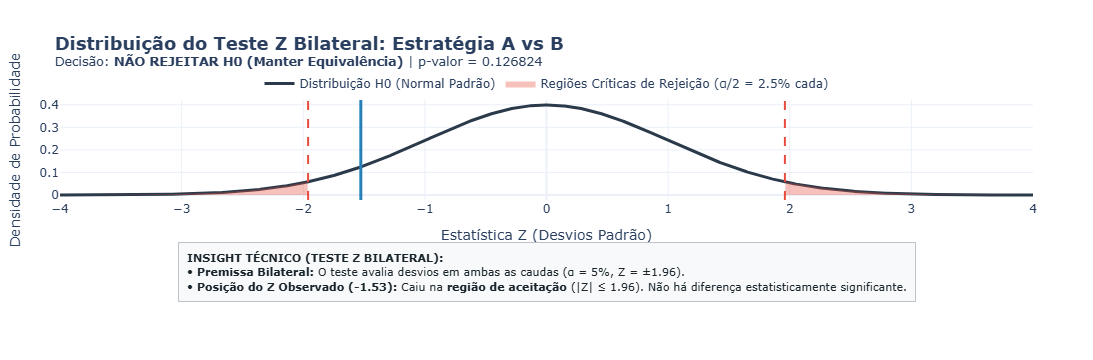

In [25]:
z_stat, p_val_z = ztest(amostra_estrategia_A, amostra_estrategia_B)

alpha = 0.05
z_critico = 1.96
x = np.linspace(-4, 4, 1000)
y = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="lines",
        name="Distribuição H0 (Normal Padrão)",
        line=dict(color="#2B3A4A", width=3),
        hovertemplate="Z: %{x:.2f}<br>Densidade: %{y:.4f}<extra></extra>",
    )
)

x_crit_sup = x[x >= z_critico]
y_crit_sup = y[x >= z_critico]
fig.add_trace(
    go.Scatter(
        x=np.concatenate([[z_critico], x_crit_sup, [4]]),
        y=np.concatenate([[0], y_crit_sup, [0]]),
        fill="tozeroy",
        fillcolor="rgba(231, 76, 60, 0.35)",
        line=dict(color="rgba(255,255,255,0)"),
        name="Regiões Críticas de Rejeição (α/2 = 2.5% cada)",
        hoverinfo="skip",
    )
)

x_crit_inf = x[x <= -z_critico]
y_crit_inf = y[x <= -z_critico]
fig.add_trace(
    go.Scatter(
        x=np.concatenate([[-4], x_crit_inf, [-z_critico]]),
        y=np.concatenate([[0], y_crit_inf, [0]]),
        fill="tozeroy",
        fillcolor="rgba(231, 76, 60, 0.35)",
        line=dict(color="rgba(255,255,255,0)"),
        showlegend=False,
        hoverinfo="skip",
    )
)

fig.add_vline(
    x=z_critico,
    line_dash="dash",
    line_color="#E74C3C",
    annotation_text=f"+{z_critico}",
    annotation_position="top right",
)
fig.add_vline(
    x=-z_critico,
    line_dash="dash",
    line_color="#E74C3C",
    annotation_text=f"-{z_critico}",
    annotation_position="top left",
)

fig.add_vline(
    x=z_stat,
    line_dash="solid",
    line_color="#27AE60" if abs(z_stat) > z_critico else "#2980B9",
    line_width=3,
    annotation_text=f"Z Observado ({z_stat:.2f})",
    annotation_position="bottom right" if z_stat >= 0 else "bottom left",
    annotation_font=dict(
        size=13, color="#27AE60" if abs(z_stat) > z_critico else "#2980B9"
    ),
)

rejeita = abs(z_stat) > z_critico
decisao_titulo = (
    "REJEITAR H0" if rejeita else "NÃO REJEITAR H0 (Manter Equivalência)"
)

texto_insight = (
    f"<b>INSIGHT TÉCNICO (TESTE Z BILATERAL):</b><br>"
    f"• <b>Premissa Bilateral:</b> O teste avalia desvios em ambas as caudas (α = 5%, Z = ±1.96).<br>"
    f"• <b>Posição do Z Observado ({z_stat:.2f}):</b> "
    + (
        f"Caiu na <b>região crítica vermelha</b> (|Z| > 1.96). A diferença é estatisticamente significante."
        if rejeita
        else f"Caiu na <b>região de aceitação</b> (|Z| ≤ 1.96). Não há diferença estatisticamente significante."
    )
)

fig.update_layout(
    title=dict(
        text=f"<b>Distribuição do Teste Z Bilateral: Estratégia A vs B</b><br><sup>Decisão: <b>{decisao_titulo}</b> | p-valor = {p_val_z:.6f}</sup>",
        font=dict(size=18),
    ),
    xaxis_title="Estatística Z (Desvios Padrão)",
    yaxis_title="Densidade de Probabilidade",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
    ),
    margin=dict(l=60, r=60, t=100, b=160),
    annotations=[
        dict(
            x=0.5,
            y=-0.42,
            xref="paper",
            yref="paper",
            text=texto_insight,
            showarrow=False,
            font=dict(size=11, color="#1A252C"),
            align="left",
            bgcolor="#F8F9FA",
            bordercolor="#BDC3C7",
            borderwidth=1,
            borderpad=8,
            xanchor="center",
            yanchor="top",
        )
    ],
)

fig.show()